In [1]:
pip install Sastrawi nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 5.2 MB/s eta 0:00:00


In [2]:
pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 10.1 MB/s eta 0:00:00


In [3]:
import nltk
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

**preproces & stem**

In [25]:
import re
import pandas as pd
import emoji
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from nltk.corpus import stopwords

# 1. LOAD EXCEL
df = pd.read_excel("reviews_casefolded.xlsx")

# STEMMER
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# pastikan kolom teks ada
print(df.columns)                 # cek kolom

# STOPWORDS (tidak hapus kata penting)
stop_words = set(stopwords.words("indonesian")).union(stopwords_custom)
stopwords_custom = set([
    "nya","mbak","devita","ya","mba","mas","loh","deh","t","di","d","ala","h","lohh","b","fifin","celsi","silvia","dll","okay","lena","agam","salma",
    "rosvina","m","yak","hapir","n","g","e","edge","iyain","thania","dng","daan","yang","untuk","dan","di","ke","dari","ini","itu","juga","kami","kamu","saya","meirizka",
    "ada","dengan","pada","karena","agar","atau","jadi","tidak","iya","yg","nya","ya","tapi","powwl","ny","nih","lahh","zxz","buat","dalam","para","akan","sudah","serta","sih","hehe","hmm","deh","mbak","mba","pool","tania",
    "mas","kak","caroline","devita","lena","dg","fifin","tp","dgn","loh","t","b","aja","imo","amoun","saja","pun","itu","anda","agar","yakni","sebagai","maka","yaitu","silvia","ad","sy","san","kpd","the","untvlantai","lo",
    "bs","d","n","sll","aztuti","dkt", "tx", "u", "anak","aku","devita","best","dj","thania","fres","asa","dll","yak","hahaha","ken","siip","kita","madam","diksh","kecil","h","yahh","x","mb","st","fo","silviaa","ka",
    "f","b","sm","tdk","nur","si","kap","m","yuuk","parpel","chelsi","dg","sgt,","tpi","se","occ","daan","an","andin","traine","trainee","s","mau","kes","asa","jd","ku","dik","welcome","dr","thania"
])


# 2. Normalisasi
normalisasi_map = {
    "yaaa":"", "saladnya":"salad", "top":"bagus", "recomendeddddd":"recomended", "pelayanannua":"layan", "std":"standar", "luarbiasa":"luar biasa", "dn":"", "bersihkan":"bersih", "mantabbbbb":"bagus", "hotelnyanya":"hotel", "mjd":"menjadi", "meetingnya":"rapat", "waitress":"waiters",
    "banyaaaaak":"banyak", "reccomanded":"recomended", "keberisihannya":"bersih", "veronica":"", "pelayananya":"layan", "dari":"", "embak":"", "gita":"", "enakkkkkk":"enak", "bnyak":"banyak", "krna":"", "bervariasiii":"bervariasi",
    "berattt":"berat", "dessertt":"desert", "adaaa":"", "dann":"", "dlu":"","bgtu":"", "smpe":"", "jugaa":"juga", "bantuain":"bantu", "enakkkkkk":"enak" ,"bgttt":"banget", "apa":"" ,"ituuu":"", "bersihh":"bersih", "luasss":"luas", "jempolll":"", "enakkk":"enak", "bolak":"", "htl":"hotel", "sdri":"", "recepcionist":"resepsionis" ,"endah":"",
    "terbaikkk":"baik", "komplit":"lengkap", "lengkaapp":"lengkap", "mantaaap":"bagus" ,"tenan":"", "bobo":"", "yo":"" ,"ah":"", "jga":"", "siiiip":"" ,"mantaaap":"bagus", "mantuuul":"", "siiiip":"", "citarasa": "cita rasa", "lekoh":"", "endull":"",
    "ramahhhh":"ramah", "enakkkk":"enak", "dahhhhayi":"", "sopia":"", "nyqman":"nyaman", "fasilitasoke":"fasilitas", "denag":"", "untu":"", "vina":"", "rramah":"ramah", "skli":"", "joss":"", "toiletries":"toilet", "masakan":"masak", "rekomend":"rekomended", "dhotel":"hotel", "dalem":"", "karyawannya":"karyawan", "mah":"", "lamaaa":"lama", "display":"", "tuh":"", "bangetttt":"banget", "enakkkkkkk":"enak",
    "amahh":"", "ramahh":"ramah",  "bakkal":"", "neng":"", "okee":"", "sip":"" ,"lezaatttt":"lezat" ,"balek":"", "prlayabab":"layan", "ekali":"", "penjrlasanya":"jelas", "kaka":"", "twraedia":"tersedia" ,"fasikitas":"fasilitas", "dehhh":"", "twmpatnya":"tempat", "you":"", "pelaynan":"layan", "nona":"", "rita":"", "hihiii":"", "cuman":"", "sihh":"", "dann":"" ,"baguuus":"bagus", "kereennn":"keren",
    "nama":"", "banyakk":"banyak", "macamm":"jenis" ,"pokoknyaa":"" ,"juaraa":"juara" ,"ririn":"" ,"namanya":"", "mantapp":"", "untukmenginap":"inap", "dish":"", "bukbernya":" buka bersama", "wi":"wifi", "fi":"", "masya":"masyaallah", "allah":"", "abis":"", "ramaah":"ramah", "yngsuper":"", "sertaaaa":"", "masakanya":"masak", "brapa":"", "terima":"terimakasih", "kasih":"", "mevvah":"mewah", "kesya"
    "bangetttt":"banget" , "kopibatau":"kopi" ,"lobbynya":"lobby","seeh":"", "direstaurannya":"restauran","pokok":"", "temenku":"teman" ,"ngadepin":"hadap", "diokein":"", "yan":"" ,"localnya":"", "mealsnya":"", "mantab":"bagus", "responnya":"respon",
    "byr": "bayar","hrus": "harus","but": "tapi","tpi": "tapi","jan": "januari","diprepare": "prepare","aps": "aplikasi","kyk": "seperti","pool": "banget","dikurangi": "kurang",
    "tlp": "telepon","feb": "februari","dlm": "dalam","sxan": "sekalian","dng": "dengan","budhenya": "bude","dikususkan": "khusus","bervariasiiii": "bervariasi","servicenya": "service",
    "raman": "ramah","beragam": "ragam","diningnya": "dining","petigas": "petugas","nutupnya": "tutup", "mmg": "memang","lwt": "lewat","belain": "bela",
    "wa": "whatsapp","sarapanya": "sarapan", "th": "tahun", "tau": "mengerti", "dimsumnya": "dimsum","rb": "ribu", "biryaninya": "briyani", "orng": "orang","klw": "jika","sxan": "sekalian",
    "terallu": "terlalu","amoun": "ampun","bgtt":"banget","bgt":"banget","bangett":"banget","byk":"banyak","inn":"in","bnget":"banget","kren":"keren","suuperr":"bagus","servicenha":"servis",
    "gpp":"gapapa","ga":"tidak","gk":"tidak","nggak":"tidak","ngga":"tidak","kram":"kran","dkt":"dekat","cek":"check","pesen":"pesan",
    "makasih":"terima kasih","mksh":"terima kasih","thx":"terima kasih","jl":"jalan","dtg":"datang","baguss":"bagus","thank you":"terimakasih",
    "oke":"baik","ok":"baik","sip":"baik","bberapa":"beberapa","asa":"aja","lg":"lagi","msk":"masuk","tv":"televisi","clear":"bersih","tsb":"tersebut","overalla":"over all",
    "rekomen":"rekomendasi","recommended":"rekomendasi","sangatt":"sangat","maknyus":"enak","topp":"bagus","thank u":"terimaksih","tengkyu":"terimakasih",
    "jg":"juga","jd":"jadi","dpt":"dapat","dapet":"dapat","apalgii":"apalagi","restorannlt":"restoran","desertnya":"desert","trmmksh":"terimakasih",
    "km":"kamu","tmn":"teman","tmpt":"tempat","tks":"terimakasih","berasa":"rasa","ksni":"kesini","sus":"aneh","baguus":"bagus","besty":"best","trimakasih":"terimakasih",
    "udh":"sudah","sdh":"sudah","blm":"belum","hr":"hari","wlopun":"walaupun","happy":"senang","bussines trip":"perjalanan bisnis","ga":"tidak",
    "kl":"kalau","klo":"kalau","kalo":"kalau","tksh":"terimakasih","cantikk":"cantik","nggk":"tidak","menservice":"servis","overall":"semua","sat set":"cepat",
    "krn":"karena","trm":"terima","trs":"terus","bgs":"bagus","breakfastnya":"breakfast","enakk":"enak","thank":"terimakasih","lt":"lantai",
    "bbrp":"beberapa","kmr":"kamar","dgn":"dengan","lbh":"lebih","enakk":"enak","baguss":"bagus","trus":"terus","gak":"tidak","bnyk":"banyak","amburadul":"berantakan",
    "mantappp":"mantap","mantapppp":"mantap","mantappppp":"mantap","sukakk":"suka","lonsay":"lontong sayur","too bad":"buruk","deal":"setuju","tgl":"tanggal","agam":"agak","kg":"juga",
    "parahh":"parah","pdhal":"padahal","tpat":"tempat","lg":"lagi","yogjakarta":"yogyakarta","pelayannann":"pelayanan","recomend":"recomended",
    "thank u":"terima kasih","utk":"untuk","org":"orang","pengkap":"lengkap","rs":"rumah sakit","breakfast":"sarapan","pdhl":"padahal","bukber":"buka bersama","hotell":"hotel",
    "bgt": "banget", "bget": "banget","bener": "benar", "bener2": "benar benar","udh": "sudah", "udah": "sudah","tdk": "tidak", "tida": "tidak", "td": "tidak",
    "dgn": "dengan", "dg": "dengan","dr": "dari","sm": "sama","tp": "tapi","yg": "yang","klo": "kalau", "kl": "kalau","krn": "karena", "karna": "karena","dpt": "dapat","bsk": "besok","bs": "bisa",
    "hr": "hari","cm": "cuma","aja": "saja","sy": "saya", "sya": "saya","km": "kamu", "kmu": "kamu","dmn": "di mana","knp": "kenapa","bgt": "banget","bgtt": "banget","jd": "jadi","gmn": "bagaimana",
    "sm": "sama","nglakuin": "melakukan", "ngelakuin": "melakukan","ngerasa": "merasa","nunggu": "menunggu","ngirim": "mengirim","ngasih": "memberi","ngambil": "mengambil","wkwk": "",
    "lol": "","btw": "omong-omong","ty": "terima kasih", "thx": "terima kasih","2x": "dua kali","1x": "sekali","gk": "tidak","ga": "tidak","ngga": "tidak","nggak": "tidak","tdk": "tidak","tbh": "tambah",
    "tp": "tapi","jg": "juga","jd": "jadi","dgn": "dengan","sm": "sama","sy": "saya","aq": "aku","gw": "saya","gue": "saya","km": "kamu","kmu": "kamu","dr": "dari","krn": "karena","pls": "tolong","plis": "tolong","bgt": "banget","bngt": "banget",
    "udh": "sudah","sdh": "sudah","dl": "dulu","blm": "belum","brp": "berapa","ttp": "tetap","ok": "baik","oke": "baik","nya": "", "mbak": "", "mba": "", "mas": "", "loh": "", "lohh": "","ya": "", "t": "", "di": "", "d": "", "ala": "", "h": "", "b": "",
    "fifin": "", "celsi": "", "silvia": "", "okay": "", "lena": "","agam": "", "salma": "", "rosvina": "", "m": "", "yak": "","hapir": "hampir", "n": "", "g": "", "e": "", "edge": "", "iyain": "iya", "thania": "", "dng": "dengan", "daan": "",
    "nya": "","mbak": "","devita": "","ya": "","mba": "","mas": "","loh": "","deh": "","t": "","di": "","d": "","ala": "","h": "","lohh": "","b": "","fifin": "","celsi": "","silvia": "","dll": "","okay": "","lena": "","agam": "","salma": "",
    "rosvina": "","m": "","yak": "","hapir": "","n": "","g": "","e": "","edge": "","iyain": "","thania": "","dng": "","daan": "","yang": "","untuk": "","dan": "","di": "","ke": "","dari": "","ini": "","itu": "","juga": "","kami": "","kamu": "","saya": "","meirizka": "",
    "ada": "","dengan": "","pada": "","karena": "","agar": "","atau": "","jadi": "","tidak": "","iya": "","yg": "","nya": "","ya": "","tapi": "","powwl": "","ny": "","nih": "","lahh": "","zxz": "",
    "buat": "","dalam": "","para": "","akan": "","sudah": "","serta": "","sih": "","hehe": "","hmm": "","deh": "","mbak": "","mba": "","pool": "","tania": "",
    "mas": "","kak": "","caroline": "","devita": "","lena": "","dg": "","fifin": "","tp": "","dgn": "","loh": "","t": "","b": "","aja": "","imo": "","amoun": "",
    "saja": "","pun": "","itu": "","anda": "","agar": "","yakni": "","sebagai": "","maka": "","yaitu": "","silvia": "","ad": "","sy": "","san": "","kpd": "","the": "","untvlantai": "","lo": "",
    "bs": "","d": "","n": "","sll": "","aztuti": "","dkt": "", "tx": "", "u": "", "anak": "","aku": "","devita": "","best": "","dj": "","thania": "","fres": "","asa": "",
    "dll": "","yak": "","hahaha": "","ken": "","siip": "","kita": "","madam": "","diksh": "","kecil": "","h": "","yahh": "","x": "","mb": "","st": "","fo": "","silviaa": "","ka": "",
    "f": "","b": "","sm": "","nur": "","si": "","kap": "","m": "","yuuk": "","parpel": "","chelsi": "","dg": "","sgt": "","tpi": "","se": "","occ": "","daan": "",
    "an": "","andin": "","traine": "","trainee": "","s": "","mau": "","kes": "","asa": "","jd": "","ku": "","dik": "","welcome": "","dr": "","thania": "",
    "istrht": "istirahat", "berteletele": "", "smua": "semua", "bambang": "", "diupgrade": "upgrade", "moment": "momen", "klau": "jika", "malem": "malam", "kenceng": "cepat", "staffnya": "staff",
    "makanannnya": "makan", "banquet": "banget", "lgs": "langsung", "gara": "karena", "ngadain": "ada", "soso": "", "bobrok": "rusak", "engga": "tidak", "managementnya": "management", "pas": "", "gt": "",
    "gaada": "tidak ada", "antre": "antri", "pencrt": "pencet", "tanggungjawabnya": "tanggung jawab", "was": "", "mgkn": "mungkin", "sblmnya": "sebelum", "spreinya": "sprei", "kalaublita": "jika",
    "drink": "minum", "by": "lewat", "freon": "", "pas": "", "mlm": "malam", "tifak": "tidak", "spertinya": "seperti", "tmtp": "tempat",
    "waiternya": "pelayan", "pelayanya": "pelayan", "impressionnya": "kesan", "ngambilin": "ambil", " wi fi": "wifi", "roomnya": "room", "disetting": "atur", "spt": "", "buanyaak": "banyak"
}

# 3. Fungsi Normalisasi
def normalize_text(text):
    words = text.split()
    new_words = []
    for w in words:
        if w in normalisasi_map: # Use the renamed dictionary
            new_words.append(normalisasi_map[w])
        else:
            new_words.append(w)
    return " ".join(new_words)


# 4. Fungsi Preprocessing Lengkap
def clean_text(text):
    text = str(text).lower()

    # 1. hapus URL, email, emoji
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)
    text = re.sub(r"\S+@\S+\.\S+", " ", text)
    text = emoji.replace_emoji(text, replace=" ")

    # 2. hapus simbol & angka
    text = re.sub(r"[^a-z\s]", " ", text)

    # 3. potong huruf berulang (enakkkkk -> enak)
    text = re.sub(r"(.)\1{2,}", r"\1", text)

    # 4. rapikan spasi
    text = re.sub(r"\s+", " ", text).strip()

    # 5. normalisasi kata (kamus)
    text = normalize_text(text)

    # 6. tokenisasi
    tokens = text.split()

    # 7. stopword removal
    tokens = [w for w in tokens if w not in stop_words]

    # 8. hapus token pendek (<=2 huruf)
    tokens = [w for w in tokens if len(w) > 2]

    # 9. stemming
    tokens = [stemmer.stem(w) for w in tokens]

    # 10. hapus kata duplikat
    tokens = list(dict.fromkeys(tokens))

    return " ".join(tokens)


# 5. Terapkan ke CSV
df["Clean_Text"] = df["Casefold"].apply(clean_text)

# simpan hasil
df.to_csv("data_clean.csv", index=False)


Index(['Casefold'], dtype='object')


In [26]:
df.head()

,Casefold,Clean_Text
0,pelayanannya ramah bgtt fasilitas kamar juga o...,layan ramah banget fasilitas kamar rekomendasi...
1,baru kali ini sangat kecewa dengan pelayanan h...,kali kecewa layan hotel mercure kota kunci kam...
2,liburan menyenangkan di jogja stay di hotel yg...,libur senang jogja stay hotel
3,lokasinya juga mantap dekat dengan bandara dan...,lokasi mantap bandara wisata kamar nyaman fasi...
4,saya merekomendasikan anda untuk menginap di h...,rekomendasi inap hotel layan bagus ramah makan...


**tf-idf**

In [34]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF Vectorizer
tfidf = TfidfVectorizer(
    max_df=0.9,        # buang kata terlalu umum
    min_df=2,          # buang kata terlalu jarang
    ngram_range=(1,2)  # unigram + bigram (opsional, bagus untuk topik)
)

# Transform teks ke vektor TF-IDF
X_tfidf = tfidf.fit_transform(df['Clean_Text'])

# Lihat ukuran matriks TF-IDF
print(X_tfidf.shape)

# (opsional) ambil nama fitur
feature_names = tfidf.get_feature_names_out()


(1216, 1746)


In [35]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. TF-IDF dari hasil preprocessing + stemming
vectorizer = TfidfVectorizer(
    max_features=500,
    min_df=2,
    max_df=0.9
)

tfidf_matrix = vectorizer.fit_transform(df["Clean_Text"].astype(str))
feature_names = vectorizer.get_feature_names_out()

# 2. Ambil 3 kata TF-IDF tertinggi per dokumen
top_words = []
top_scores = []

for row in tfidf_matrix.toarray():
    idx = np.argsort(row)[::-1][:3]
    words = [(feature_names[i], row[i]) for i in idx if row[i] > 0]

    if words:
        top_words.append(", ".join([w for w, s in words]))
        top_scores.append(", ".join([str(round(s, 4)) for w, s in words]))
    else:
        top_words.append("-")
        top_scores.append("-")

# 3. Tabel interpretasi (BELUM ADA CLUSTER)
df_output = pd.DataFrame({
    "Kalimat_Bersih": df["Clean_Text"],
    "Kata_Terkuat_TFIDF": top_words,
    "Skor_TFIDF": top_scores
})

print(df_output.head())


                                      Kalimat_Bersih  \
0  layan ramah banget fasilitas kamar rekomendasi...   
1  kali kecewa layan hotel mercure kota kunci kam...   
2                      libur senang jogja stay hotel   
3  lokasi mantap bandara wisata kamar nyaman fasi...   
4  rekomendasi inap hotel layan bagus ramah makan...   

                 Kata_Terkuat_TFIDF              Skor_TFIDF  
0        wisata, libur, rekomendasi  0.5188, 0.4265, 0.3942  
1               suami, kunci, susah   0.407, 0.3934, 0.3731  
2               stay, libur, senang   0.5404, 0.501, 0.4528  
3             bandara, wisata, staf   0.4546, 0.4485, 0.371  
4  simpan, resepsionis, rekomendasi    0.567, 0.4789, 0.373  


**elbow**

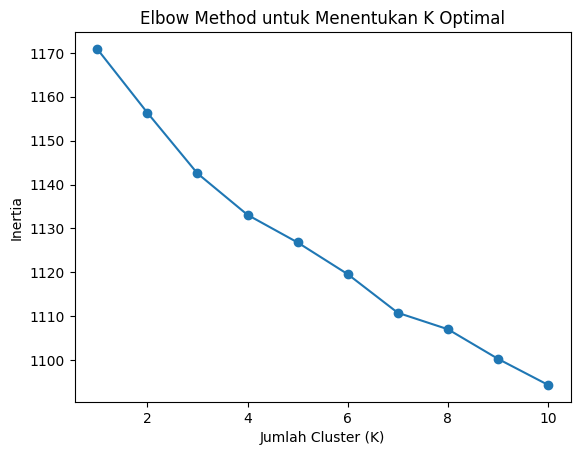

In [36]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Tentukan range jumlah cluster
k_range = range(1, 11)
inertia = []

# Hitung inertia untuk tiap K
for k in k_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_tfidf)
    inertia.append(kmeans.inertia_)

# Plot Elbow
plt.figure()
plt.plot(k_range, inertia, marker='o')
plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method untuk Menentukan K Optimal")
plt.show()


**k-means**

In [37]:
from sklearn.cluster import KMeans

# Inisialisasi K-Means dengan K optimal = 3
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

# Fit dan prediksi cluster
df['cluster'] = kmeans.fit_predict(X_tfidf)

# Lihat distribusi jumlah data per cluster
print(df['cluster'].value_counts().sort_index())


cluster
0    808
1    196
2    212
Name: count, dtype: int64


In [39]:
import numpy as np

# Ambil centroid cluster
centroids = kmeans.cluster_centers_

# Ambil nama fitur (kata)
# FIX: Use the 'tfidf' vectorizer from cell nC1aRxxVN1Lf, which has 1746 features,
# to match the dimensions of the centroids from the kmeans model fitted on X_tfidf.
terms = tfidf.get_feature_names_out()

# Jumlah kata teratas per cluster
top_n = 10

for i, centroid in enumerate(centroids):
    top_indices = centroid.argsort()[::-1][:top_n]
    top_terms = [terms[j] for j in top_indices]
    print(f"Cluster {i}: {', '.join(top_terms)}")

Cluster 0: layan, kamar, hotel, nyaman, ramah, bersih, bagus, makan, lokasi, strategis
Cluster 1: sarap, sarap enak, enak, layan, menu, menu sarap, lengkap, pagi, sarap pagi, bantu
Cluster 2: makan enak, makan, enak, layan, ramah, enak layan, bagus, layan ramah, nyaman, layan bagus


In [41]:
cluster_label = {
    0: "Fasilitas, Kenyamanan, dan Lokasi Hotel",
    1: "Sarapan dan Menu Makanan",
    2: "Kualitas Pelayanan"
}

df['topik_cluster'] = df['cluster'].map(cluster_label)


In [42]:
df['cluster'] = kmeans.labels_
df['topik_cluster'] = df['cluster'].map(cluster_label)


In [43]:
cluster_keywords = {
    0: "layan, kamar, hotel, nyaman, ramah, bersih, bagus, makan, lokasi, strategis",
    1: "sarap, enak, menu, pagi, lengkap, bantu",
    2: "makan, enak, layan, ramah, bagus, nyaman"
}

df['kata_dominan'] = df['cluster'].map(cluster_keywords)


In [45]:
df_hasil = df[[
    'Clean_Text',
    'cluster',
    'topik_cluster',
    'kata_dominan'
]]

df_hasil.head(10)


,Clean_Text,cluster,topik_cluster,kata_dominan
0,layan ramah banget fasilitas kamar rekomendasi...,0,"Fasilitas, Kenyamanan, dan Lokasi Hotel","layan, kamar, hotel, nyaman, ramah, bersih, ba..."
1,kali kecewa layan hotel mercure kota kunci kam...,0,"Fasilitas, Kenyamanan, dan Lokasi Hotel","layan, kamar, hotel, nyaman, ramah, bersih, ba..."
2,libur senang jogja stay hotel,0,"Fasilitas, Kenyamanan, dan Lokasi Hotel","layan, kamar, hotel, nyaman, ramah, bersih, ba..."
3,lokasi mantap bandara wisata kamar nyaman fasi...,0,"Fasilitas, Kenyamanan, dan Lokasi Hotel","layan, kamar, hotel, nyaman, ramah, bersih, ba..."
4,rekomendasi inap hotel layan bagus ramah makan...,2,Kualitas Pelayanan,"makan, enak, layan, ramah, bagus, nyaman"
5,menu resto lengkap layan banget terimakasih,0,"Fasilitas, Kenyamanan, dan Lokasi Hotel","layan, kamar, hotel, nyaman, ramah, bersih, ba..."
6,sarap lengkap enak layan bagus,1,Sarapan dan Menu Makanan,"sarap, enak, menu, pagi, lengkap, bantu"
7,layan bagus nyaman recomended,0,"Fasilitas, Kenyamanan, dan Lokasi Hotel","layan, kamar, hotel, nyaman, ramah, bersih, ba..."
8,menu variatif enak pilih desert,0,"Fasilitas, Kenyamanan, dan Lokasi Hotel","layan, kamar, hotel, nyaman, ramah, bersih, ba..."
9,staff ramah tutup kurang terimakasih too bad k...,0,"Fasilitas, Kenyamanan, dan Lokasi Hotel","layan, kamar, hotel, nyaman, ramah, bersih, ba..."
